### 8. 이미지를 위한 인공 신경망
#### 8-1. 합성곱 신경망의 구성 요소 

|용어|정의|역할|
|---|---|---|
|뉴런 (Neuron)|인공 신경망의 기본 처리 단위|입력을 받아 가중치와 결합하여 출력을 생성|
|필터 (Filter)|CNN의 합성곱 계층을 이루는 작은 가중치 행렬|입력의 특정 공간적 특징을 추출|
|커널 (Kernel)|필터와 동일한 의미로 사용됨|합성곱 연산에 사용되는 작은 행렬|

**특성 맵(feature map)**: 합성곱 계산을 통해 얻은 출력

---

##### 케라스 합성곱 층

`Conv2D 클래스`는 2차원 입력(이미지)에 합성곱 연산을 적용하는 레이어

- 패딩 (Padding)

    패딩은 합성곱 연산을 수행하기 전에 입력 배열의 주위를 가상의 값(보통 0)으로 채우는 것

    - 세임 패딩 (Same Padding)

        목표: 합성곱 연산 후에도 입력의 가로세로 크기와 특성 맵(출력)의 가로세로 크기를 동일하게 유지하기 위해 사용

        방법: 입력 주위에 필요한 만큼 0으로 채움

    - 밸리드 패딩 (Valid Padding)

        목표: 패딩을 전혀 하지 않고 오직 입력 배열의 원본 값에 대해서만 합성곱을 수행

        결과: 특성 맵의 크기는 입력보다 작아짐

- 스트라이드 (Stride)

    스트라이드는 **필터(커널)**가 입력 위를 얼마나 크게 이동할지를 결정하는 크기

    - stride=1: 필터가 한 칸씩 이동합니다 (가장 일반적)
    
    - stride=2: 필터가 두 칸씩 건너뛰어 이동합니다. 스트라이드가 커지면 특성 맵의 크기가 더 빠르게 줄어듭니다.

- 풀링 (Pooling)

    풀링은 합성곱 층에서 추출된 특성 맵의 가로세로 크기를 줄이는 역할

    이는 매개변수 수를 줄여 연산 속도를 높이고, 모델의 **과대적합(Overfitting)**을 방지하는 것을 도움

    - 최대 풀링 (Max Pooling)
        
        도장을 찍은 영역(풀링 윈도우) 내에서 가장 큰 값 하나만을 선택하여 출력

        **가장 중요한 특징(가장 큰 활성화 값)** 을 보존하는 효과가 있음

        ```Python
        MaxPooling2D(
            pool_size=(2, 2),  # 풀링의 크기 (도장의 크기)
            strides=(2, 2),    # 이동의 크기 (두 칸씩 이동)
            padding='valid'    # 패딩 방식 (패딩 없음)
        )

    - 평균 풀링 (Average Pooling):

        도장을 찍은 영역 내의 모든 값들의 평균값을 계산하여 출력합니다.

        특징의 전반적인 정보를 부드럽게 요약하는 데 사용됩니다.



```python
keras.layers.Conv2D(10, kernel_size=(3,3), activation='relu',
                    padding='same', strides=1)

---

##### 합성곱 신경망의 전체 구조 

<img src="https://github.com/HANISY/AI-Study/blob/main/img/CNN.png?raw=true" width=1000>

1. 합성곱 층 (Convolutional Layer)

    - 역할: 이미지에서 특징 (선, 모서리 등)을 추출

    - 작동: 3개의 (3, 3) 필터가 입력 위를 훑으며 계산 (스트라이드 1).

    - 패딩: 세임 패딩을 사용하여 입력 크기 **(4, 4)**와 출력 크기가 동일하게 유지

    - 결과: (4, 4, 3) 크기의 특성 맵이 만들어지고, 여기에 렐루(ReLU) 활성화 함수가 적용

2. 풀링 층 (Pooling Layer)

    - 역할: 추출된 특성 맵의 크기를 줄여 정보를 압축하고 연산을 효율적으로 만듬

    - 작동: (2, 2) 최대 풀링을 사용해 영역 내에서 가장 큰 값만 선택

    - 결과: 특성 맵 크기가 절반으로 줄어 **(2, 2, 3)**이 됨 (특성 맵 개수는 유지).

3. 밀집층 (Fully Connected Layer)

    - 역할: 압축된 특징 정보를 바탕으로 최종적으로 분류를 예측

    - 작동: 차원 펼치기 (Flatten) - (2, 2, 3) 배열을 12개의 원소를 가진 1차원 배열로 변환

    - 출력: 3개의 뉴런을 가진 출력층으로 전달되어 최종 계산을 수행

    - 최종 예측: 소프트맥스(Softmax) 함수를 거쳐 3가지 클래스에 대한 확률로 최종 분류 결과를 얻음

▶ CNN은 **특징 추출(합성곱) → 압축(풀링)** 의 쌍을 통해 데이터를 처리한 후, **최종 분류(밀집층)** 로 연결

---

**컬러 이미지를 사용한 합성곱**

1. 3차원 입력 (깊이/채널)

    - 흑백 이미지: 2차원 배열로 표현 (예: (4, 4))

    - 컬러 이미지: RGB (빨강, 초록, 파랑) 채널로 구성되어 3차원 배열로 표현 (예: (너비, 높이, 깊이) → (4, 4, 3))

        깊이 차원: 컬러 이미지의 경우 RGB 채널 수인 3

    - Keras의 기본: 케라스의 합성곱 층 (Conv2D)은 흑백 이미지일지라도 깊이 차원이 1인 3차원 배열을 입력으로 기대

        (예: (28, 28) $\rightarrow$ (28, 28, 1))

2. 3차원 합성곱의 수행

    - 필터 커널의 크기: 입력이 깊이를 가지면, 필터(커널)도 입력과 같은 깊이를 가져야 함
        
        입력이 **(4, 4, 3)**이면, 필터 커널 크기는 **(3, 3, 3)**이 됨

    - 연산: 필터 커널의 모든 원소(예: $3 \times 3 \times 3 = 27$개)와 입력 영역의 모든 원소를 곱하고 더한 후 절편을 더함

    - 출력: 입력이나 필터의 차원에 관계없이, 이 하나의 합성곱 연산 결과는 항상 하나의 값이 되어 특성 맵의 한 원소를 채움

        (깊이가 사라짐)

3. 층을 쌓을 때의 변화

    - 후속 층의 필터 깊이: CNN에서 합성곱 층 뒤에 또 다른 합성곱 층이 올 때, 두 번째 층의 필터 깊이는 첫 번째 층의 특성 맵 깊이와 같아야 함

        예: 이전 층의 출력이 **(4, 4, 5)**라면, 다음 필터 커널의 크기는 **(3, 3, 5)**

    - CNN의 특징:

        - 너비와 높이: 합성곱 층과 풀링 층을 거치면서 점점 줄어듬 (특징이 위치에 상관없이 잘 감지되도록)

        - 깊이 (채널): 필터 개수를 늘리면서 점점 깊어짐 (다양하고 복잡한 특징을 감지할 수 있도록)


▶ 정리

- 특징 학습: 합성곱 층이 깊어질수록 간단한 특징 (선, 곡선)에서 복잡한 특징으로 학습

- 분류: 마지막에 풀링을 거친 특성 맵을 1차원으로 펼쳐서 밀집층(출력층)의 입력으로 사용해 최종 분류를 수행


---

#### 8-2. 합성곱 신경망을 사용한 이미지 분류

In [1]:
# 패션 MNIST 데이터 불러오기
import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()
train_scaled = train_input.reshape(-1, 28, 28, 1) / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

2025-12-02 14:23:01.424926: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 14:23:01.437114: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764652981.453872   30271 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764652981.457402   30271 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-02 14:23:01.470805: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

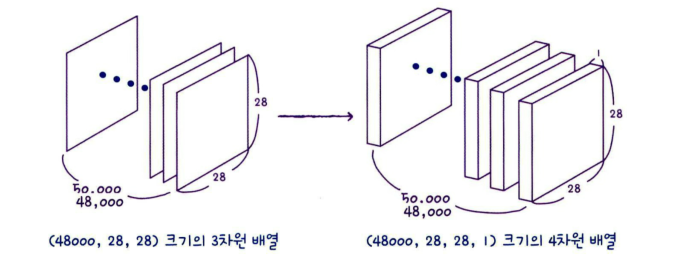

##### 합성곱 신경망 만들기

In [2]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28, 1)))            
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu',     # 첫 번째 합성곱 층인 Conv2D를 추가
                              padding='same'))

W0000 00:00:1764652985.260575   30271 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
# 풀링 층 추가 
model.add(keras.layers.MaxPooling2D(2))

In [4]:
# 첫번째 합성곱-풀링 층 다음에 두 번째 합성곱-풀링 층을 추가 
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu',     # 필터의 개수를 64개로 늘림
                              padding='same'))
model.add(keras.layers.MaxPooling2D(2))

In [5]:
# Flatten 클래스 다음에 Dense 은닉층, 마지막으로 Dense 출력층의 순서대로 구성
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.4))                    # 은닉층의 과대적합을 막아 성능을 개선 
model.add(keras.layers.Dense(10, activation='softmax'))

In [6]:
# 모델 구조 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       313,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,526 (1.27 MB)

 Trainable params: 333,526 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

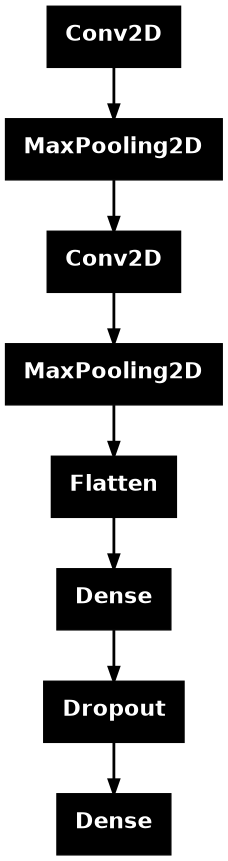

In [7]:
# 층의 구성을 그림으로 표현
keras.utils.plot_model(model, dpi=100, )

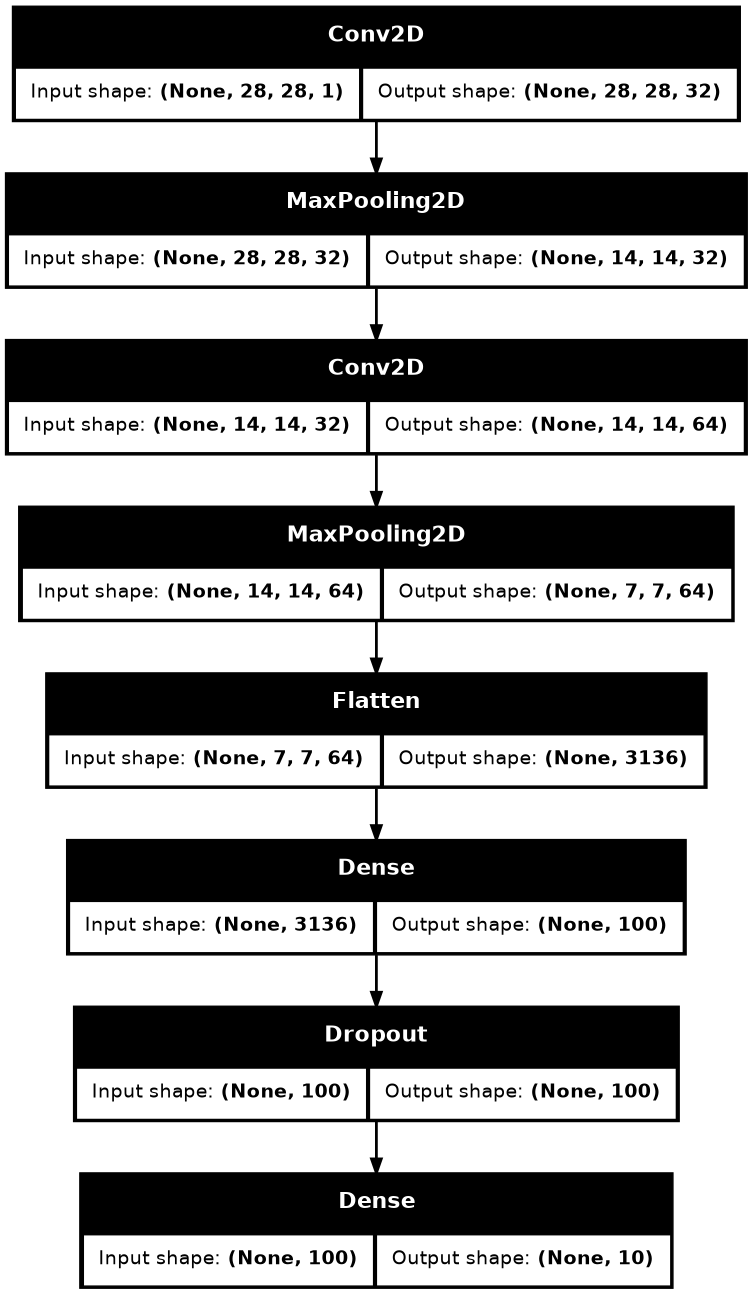

In [8]:
keras.utils.plot_model(model, show_shapes=True, dpi=100)

----

##### 모델 컴파일과 훈련

In [9]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
chechpoint_cb = keras.callbacks.ModelCheckpoint('best-cnn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, 
                                                  restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20,
                    validation_data=(val_scaled, val_target),
                    callbacks=[chechpoint_cb, early_stopping_cb])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.7393 - loss: 0.7319 - val_accuracy: 0.8796 - val_loss: 0.3278
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.8680 - loss: 0.3613 - val_accuracy: 0.8970 - val_loss: 0.2808
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8916 - loss: 0.2999 - val_accuracy: 0.9062 - val_loss: 0.2509
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9031 - loss: 0.2711 - val_accuracy: 0.9086 - val_loss: 0.2548
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9126 - loss: 0.2396 - val_accuracy: 0.9080 - val_loss: 0.2419
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9179 - loss: 0.2216 - val_accuracy: 0.9143 - val_loss: 0.2386
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9248 - loss: 0.2066 - val_accuracy: 0.9178 - val_loss: 0.2240
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9280 -

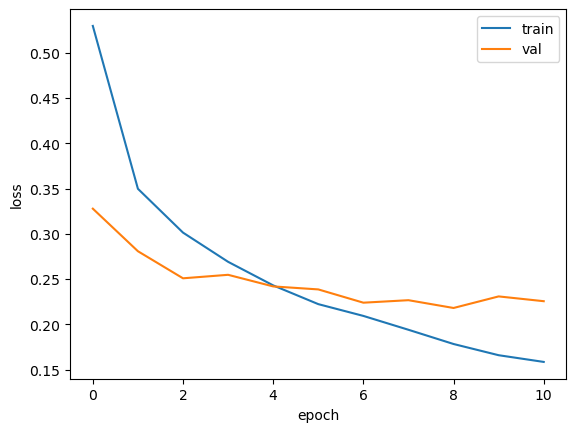

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

EarlyStopping 클래스에서 restore_best_weights 매개변수를 True로 지정했으므로 

현재 model 객체가 최적의 모델 파라미터로 복원되어 있음

즉 ModelCheckpoint 콜백이 저장한 best-cnn-model.keras 파일을 다시 읽을 필요가 없음 

In [11]:
# 세트에 대한 성능 평가 
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9248 - loss: 0.2077


[0.2181229293346405, 0.9225833415985107]

fit () 메서드의 출력 중 여섯 번째 에포크의 출력과 유사  

즉, EarlyStopping 콜백이 model 객체를 최상의 모델 파라미터로 복원함 

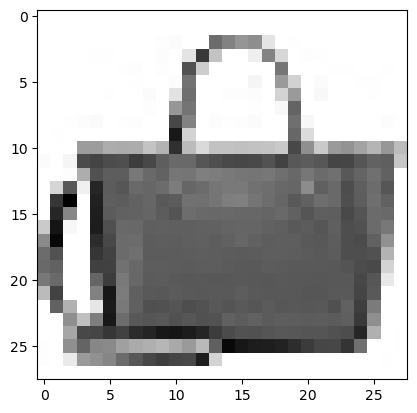

In [12]:
# 훈련된 모델을 사용하여 새로운 데이터 예측
# 편의상 검증 세트의 첫 번째 샘플을 처음 본 이미지로 가정
# 첫 번째 샘플 이미지 확인
plt.imshow(val_scaled[0].reshape(28, 28), cmap='gray_r')
plt.show()

In [13]:
# 모델이 이 이미지에 대해 어떤 예측을 만드는지 확인
# predict() 10개의 클래스에 대한 예측 확률을 출력
preds = model.predict(val_scaled[0:1])          # 배열 슬라이싱은 전체 차원을 유지 
print(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[1.55287295e-20 1.41953721e-29 5.04159914e-19 5.83434433e-18
  1.27227856e-17 1.08555575e-23 1.47937362e-19 1.11791622e-21
  1.00000000e+00 5.40980866e-22]]


아홉 번째 값이 1이고, 다른 값은 거의 0에 가까움

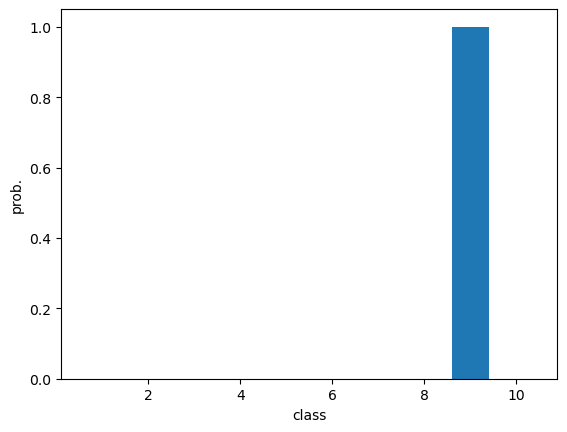

In [14]:
# 막대그래프로 확인
plt.bar(range(1,11), preds[0])
plt.xlabel('class')
plt.ylabel('prob.')
plt.show()

In [15]:
# 데이터셋의 레이블을 리스트로 저장
classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠 ']

In [16]:
# preds 배열에서 가장 큰 인덱스를 찾아 classes 리스트의 인덱스로 사용 
import numpy as np

print(classes[np.argmax(preds)])

가방


In [17]:
# 이 모델을 실전에 투입했을 때 얻을 수 있는 예상 성능 측정
test_scaled = test_input.reshape(-1, 28, 28, 1) / 255.0

In [18]:
# 테스트 세트에 대한 성능 측정
model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9188 - loss: 0.2458


[0.24183915555477142, 0.9175000190734863]

이 모델을 실전에 투잆하여 패션 아이템을 분류한다면 **약 91%** 의 성능 기대 가능!

---

#### 8-3. 합성곱 신경망의 시각화 

##### 가중치 시각화 

**가중치**: 입력 이미지의 2차원 영역에 적용되어 어떤 특징을 크게 두드러지게 표현하는 역할

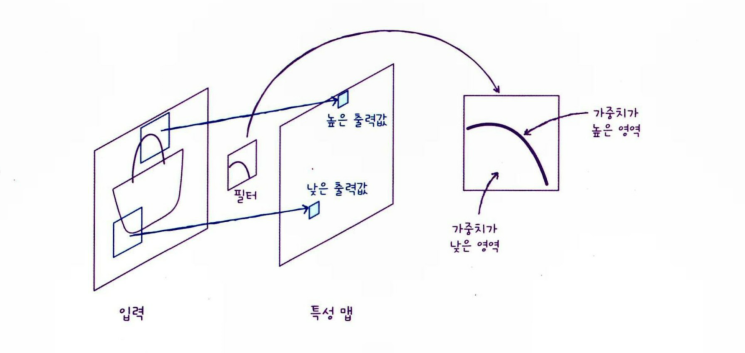

In [19]:
# 모델이 어떤 가중치를 학습했는지 확인
import keras
model = keras.models.load_model('best-cnn-model.keras')

In [20]:
model.layers

[<Conv2D name=conv2d, built=True>,
 <MaxPooling2D name=max_pooling2d, built=True>,
 <Conv2D name=conv2d_1, built=True>,
 <MaxPooling2D name=max_pooling2d_1, built=True>,
 <Flatten name=flatten, built=True>,
 <Dense name=dense, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=True>]

In [21]:
# 첫 번째 합성곱 층의 가중치 조사 
# 층의 가중치와 절편은 weights 속성에 저장
conv = model.layers[0]
print(conv.weights[0].shape, conv.weights[1].shape)

(3, 3, 1, 32) (32,)


In [22]:
# 가중치 배열의 평균과 표준편차를 계산
conv_weights = conv.weights[0].numpy()
print(conv_weights.mean(), conv_weights.std())

-0.013583987 0.23523605


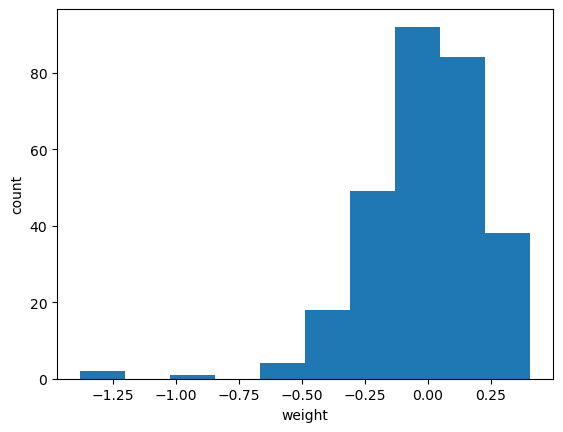

In [23]:
# 가중치의 분포 확인
import matplotlib.pyplot as plt

plt.hist(conv_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

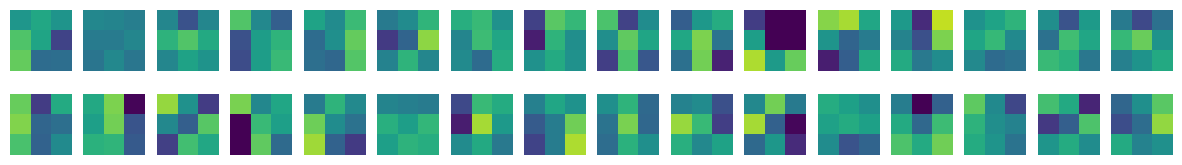

In [24]:
# 32개의 커널을 16개씩 두 줄로 출력
fig, axs = plt.subplots(2, 16, figsize=(15, 2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(conv_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)     #imshow() 배열에 있는 최댓값과 최솟값을 사용해 픽셀의 강도를 표현
        axs[i, j].axis('off')
plt.show()

합성곱 신경망에서 픽셀은 단순한 밝기 값에서 시작하여, 

층을 거칠수록 컴퓨터가 대상을 인식하기 위해 학습한 점점 더 복잡하고 의미 있는 특징의 강도를 나타내는 값으로 변화

In [25]:
# 훈련하지 않은 빈 합성곱 신경망 만들기
no_training_model = keras.Sequential()
no_training_model.add(keras.layers.Input(shape=(28, 28, 1)))
no_training_model.add(keras.layers.Conv2D(32, kernel_size=3, activation=\
                                          'relu', padding='same'))

In [26]:
# 모델의 첫 번째 층의 가중치를 no_training_conv 변수에 저장
no_training_conv = no_training_model.layers[0]
print(no_training_conv.weights[0].shape)

(3, 3, 1, 32)


In [27]:
# 가중치의 평균과 표준편차 확인
no_training_weights = no_training_conv.weights[0].numpy()
print(no_training_weights.mean(), no_training_weights.std())

0.007366225 0.08021196


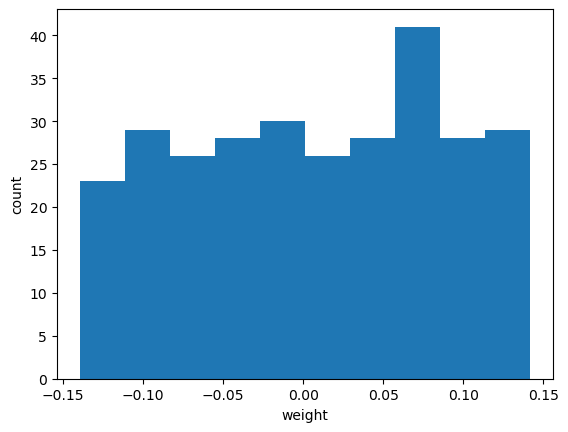

In [28]:
plt.hist(no_training_weights.reshape(-1, 1))
plt.xlabel('weight')
plt.ylabel('count')
plt.show()

케라스가 신경망의 가중치를 처음 초기화할 때 균등 분포에서 랜덤하게 값을 선택하기 때문에 고른 분포를 보임

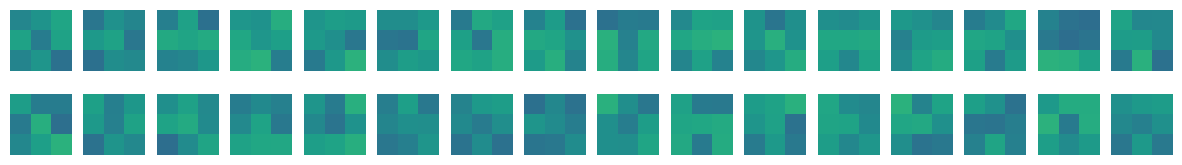

In [29]:
fig, axs = plt.subplots(2, 16, figsize=(15,2))
for i in range(2):
    for j in range(16):
        axs[i, j].imshow(no_training_weights[:,:,0,i*16 + j], vmin=-0.5, vmax=0.5)
        axs[i, j].axis('off')
plt.show()

---

##### 함수형 API

In [30]:
# Dense 층 2개로 이루어진 완전 연결 신경망을 함수형 API로 구현
# 입력층과 2개의 Dense 층 객체 만들기
inputs = keras.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='relu')
dense2 = keras.layers.Dense(10, activation='softmax')

In [32]:
# 함수처럼 호출
hidden = dense1(inputs)

In [35]:
# 두 번째 층 호출
outputs = dense2(hidden)

In [ ]:
# inputs와 outputs를 Model 클래스로 연결
func_model = keras.Model(inputs, outputs)

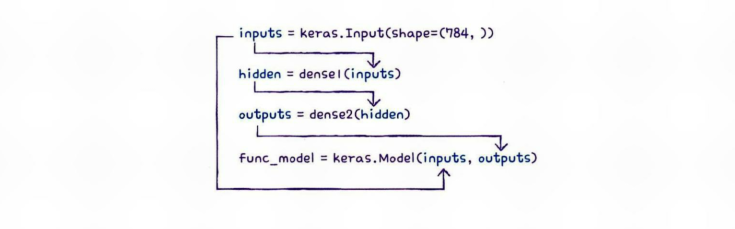

model 객체의 predict() 메서드를 호출하면 입력부터 마지막 층까지 모든 계산을 수행한 후 최종 출력을 반환

In [37]:
# model 객체의 입력 참조 
print(model.inputs)

[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, name=input_layer>]


In [ ]:
conv_acti = keras.Model(model.inputs[0], model.layers[0].output)

----

##### 특성 맵 시각화

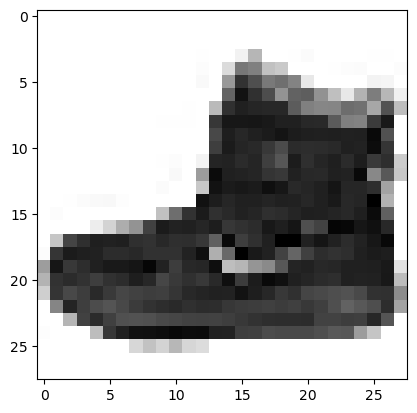

In [42]:
# 훈련 세트에 있는 첫 샘플 그리기 
(train_input, train_target), (test_input, test_target) =\
    keras.datasets.fashion_mnist.load_data()
plt.imshow(train_input[0], cmap='gray_r')
plt.show()

In [ ]:
# conv_acti 모델에 주입하여 Conv2D 층이 만드는 특성 맵을 출력
ankle_boot = train_input[0:1].reshape(-1, 28, 28, 1) / 255.0        
feature_maps = conv_acti.predict(ankle_boot)        # predict() 메서드는 항상 입력의 첫 번째 차원이 배치 차원일 것으로 기대
                                                    # 슬라이싱 연산자를 이용하여 첫 번째 샘플 선택

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


In [45]:
# conv_acti.predict() 메서드가 출력한 feature_maps의 크기 확인
print(feature_maps.shape)

(1, 28, 28, 32)


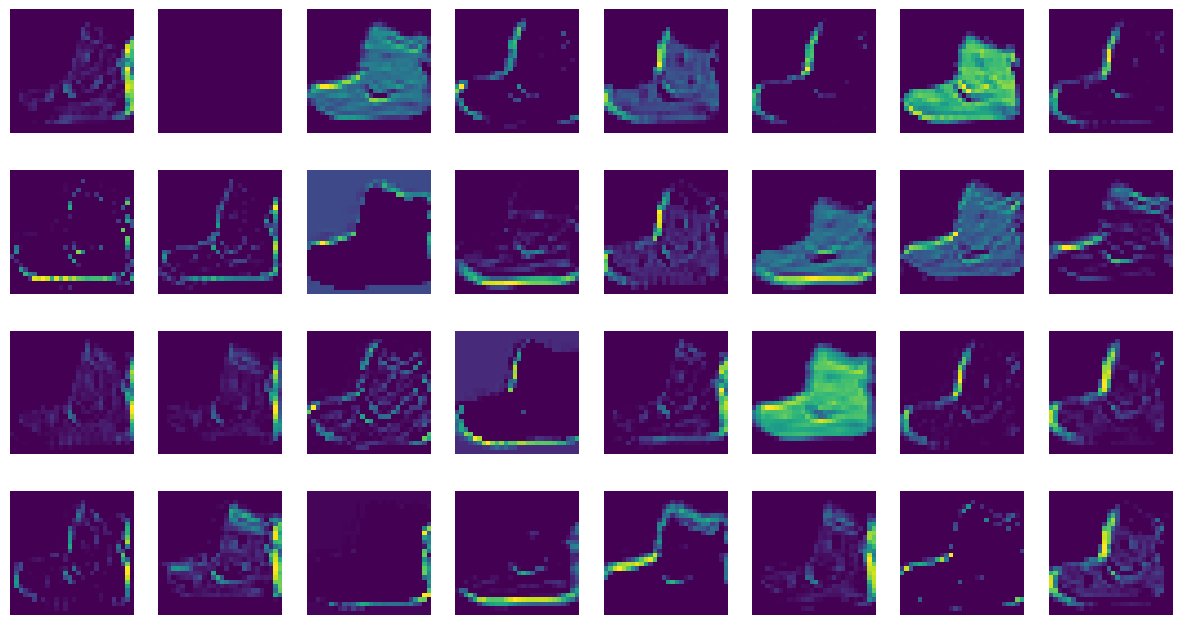

In [ ]:
# 특성 맵 그리기 
# 32개의 필터르르 통해 입력 이미지에서 강하게 활성화된 부분 표현
fig, axs = plt.subplots(4, 8, figsize=(15, 8))
for i in range(4):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()

In [47]:
# 두 번째 합성곱 층이 만든 특성 맵 확인
conv2_acti = keras.Model(model.inputs[0], model.layers[2].output)

In [48]:
# 앵클 부츠 샘플을 conv2_acti 모델의 predict() 메서드에 전달
feature_maps = conv2_acti.predict(ankle_boot) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [50]:
# 특성 맵 크기 확인
print(feature_maps.shape)

(1, 14, 14, 64)


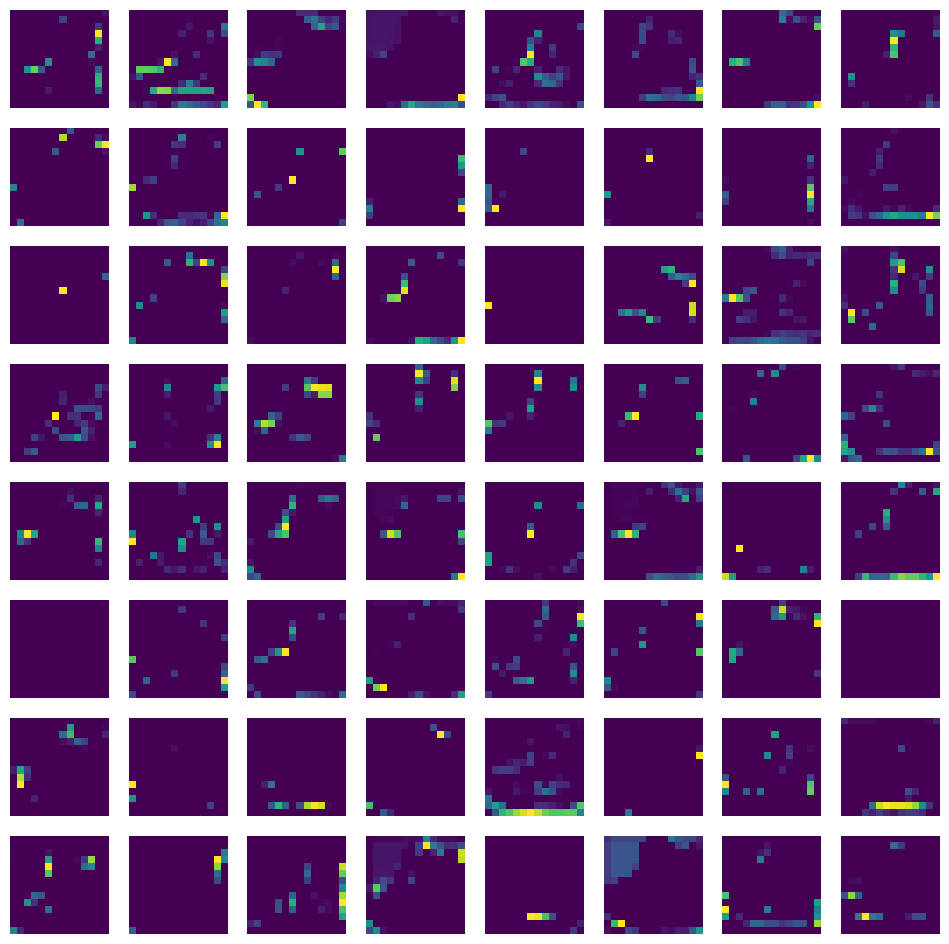

In [51]:
# 특성 맵 그리기
fig, axs = plt.subplots(8, 8, figsize=(12, 12))
for i in range(8):
    for j in range(8):
        axs[i, j].imshow(feature_maps[0,:,:,i*8 + j])
        axs[i, j].axis('off')
plt.show()

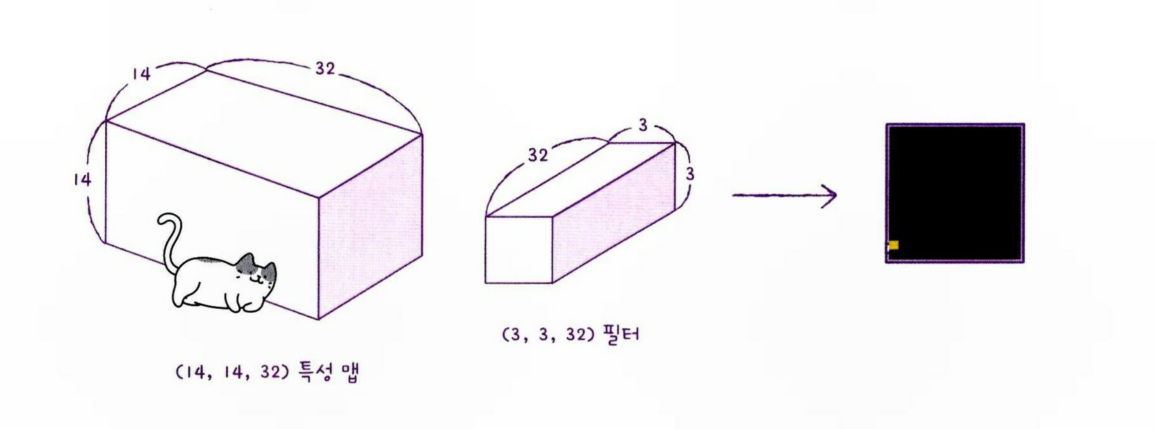

특성 맵에서 어떤 부위를 감지하는지 직관적으로 이해하기 어려움

---

##### 합성곱 신경망(CNN) 핵심 원리 요약
1. 계층적 특징 추출 (Hierarchical Feature Extraction)

- 얕은 층: 경계, 색깔 같은 단순한 저수준 특징을 감지

- 깊은 층: 이러한 특징들을 조합하여 추상적이고 복잡한 고수준 특징을 감지

2. 필터(커널)와 크기

- 커널 크기: 효율성과 성능을 위해 **(3, 3)** 과 같은 작은 커널을 여러 층에 사용하는 것이 일반적

- 3차원 합성곱: 컬러 이미지처럼 입력에 **깊이(채널)** 가 있으면, 커널 역시 입력과 같은 깊이를 가져야 함

    연산 결과는 항상 하나의 값이 됨

3. 특성 맵의 크기 변화

- CNN 층을 거듭할수록 특성 맵은 다음과 같이 변화

    - 높이/너비: 줄어듬 (정보 압축)

    - 채널 (깊이): 늘어남 (더 많은 특징 학습)

- 크기 축소의 주된 방법: 특성 맵의 크기를 줄이는 주된 방법은 **풀링 층(Pooling Layer)** 을 사용하는 것